# Workforce Headcount — Forecasting

This notebook projects future headcount and salary cost for each department,
building on the patterns found in the exploration notebook (a growth trend +
yearly seasonality).

**It does three things:**

1. **Forecasts with two methods**, so you can compare:
   - A simple, explainable **baseline** (average by calendar month).
   - **Holt-Winters** exponential smoothing (models trend + seasonality).
2. **Lets a planner apply manual overrides** to hires and leavers, per month —
   so known future events (a hiring class, a freeze, a restructure) can be
   layered on top of the statistical forecast.
3. **Translates headcount into salary cost**, turning the workforce plan into
   a budget number.

> All the forecasting logic lives in `src/forecast.py` so the notebook stays
> readable and the same code can power the Streamlit app. We just call it here.

## 1. Setup

In [1]:
# Standard tools, plus our own forecasting module from the src folder.
import sys
sys.path.insert(0, "../src")   # so Python can find forecast.py

import pandas as pd
import matplotlib.pyplot as plt
from forecast import forecast_department

# Load the historical data.
df = pd.read_csv("../data/headcount_data.csv", parse_dates=["date"])

# We'll forecast Engineering throughout this notebook because it has the
# clearest growth trend. You can change this to any department name.
DEPARTMENT = "Engineering"
HORIZON = 12   # forecast 12 months ahead

# Pull the chosen department's history for plotting.
history = df[df["department"] == DEPARTMENT].sort_values("date")
print(f"Forecasting {DEPARTMENT}, {HORIZON} months ahead.")
print(f"Last known headcount: {history['headcount'].iloc[-1]}")

Forecasting Engineering, 12 months ahead.
Last known headcount: 110


## 2. Method 1 — the simple baseline

The baseline forecasts each future month using the **historical average for
that calendar month**. To predict next March's hires, it averages all past
Marches. Simple, transparent, and easy for a finance team to check by hand —
and it still captures the Q1-high / summer-low seasonality.

In [2]:
# Call our module with method="baseline". It returns a table with the
# projected hires, leavers, headcount, and salary cost for each future month.
baseline_fc = forecast_department(df, DEPARTMENT, periods=HORIZON, method="baseline")
baseline_fc

,date,department,hires,leavers,headcount,monthly_salary_cost,monthly_payroll_tax,monthly_benefits,monthly_overhead,monthly_total_cost
0,2025-01-01,Engineering,2,0,112,1325842.09,101426.92,159101.05,132584.21,1718954.27
1,2025-02-01,Engineering,2,0,114,1352846.12,103492.73,162341.53,135284.61,1753964.99
2,2025-03-01,Engineering,2,1,115,1368078.94,104658.04,164169.47,136807.89,1773714.35
3,2025-04-01,Engineering,2,0,117,1395304.35,106740.78,167436.52,139530.44,1809012.09
4,2025-05-01,Engineering,1,0,118,1410700.64,107918.60,169284.08,141070.06,1828973.38
5,2025-06-01,Engineering,1,0,119,1426164.38,109101.58,171139.73,142616.44,1849022.12
6,2025-07-01,Engineering,1,0,120,1441695.82,110289.73,173003.50,144169.58,1869158.63
7,2025-08-01,Engineering,2,1,121,1457295.19,111483.08,174875.42,145729.52,1889383.22
8,2025-09-01,Engineering,3,0,124,1497109.67,114528.89,179653.16,149710.97,1941002.69
9,2025-10-01,Engineering,2,0,126,1525008.43,116663.14,183001.01,152500.84,1977173.43


## 3. Method 2 — Holt-Winters exponential smoothing

Holt-Winters is a classic, widely trusted method that models a **trend** and a
repeating **seasonal pattern** at the same time, weighting recent data more
heavily. It's more capable than the baseline but still interpretable — not a
black box.

In [3]:
# Same function, method="holt_winters".
hw_fc = forecast_department(df, DEPARTMENT, periods=HORIZON, method="holt_winters")
hw_fc

,date,department,hires,leavers,headcount,monthly_salary_cost,monthly_payroll_tax,monthly_benefits,monthly_overhead,monthly_total_cost
0,2025-01-01,Engineering,4,1,113,1337679.97,102332.52,160521.60,133768.00,1734302.08
1,2025-02-01,Engineering,4,1,116,1376580.26,105308.39,165189.63,137658.03,1784736.31
2,2025-03-01,Engineering,4,1,119,1415664.30,108298.32,169879.72,141566.43,1835408.76
3,2025-04-01,Engineering,3,1,121,1443007.06,110390.04,173160.85,144300.71,1870858.66
4,2025-05-01,Engineering,3,1,123,1470476.09,112491.42,176457.13,147047.61,1906472.25
5,2025-06-01,Engineering,2,1,124,1486087.25,113685.67,178330.47,148608.73,1926712.12
6,2025-07-01,Engineering,2,1,125,1501766.48,114885.14,180211.98,150176.65,1947040.24
7,2025-08-01,Engineering,3,1,127,1529557.76,117011.17,183546.93,152955.78,1983071.64
8,2025-09-01,Engineering,4,1,130,1569550.46,120070.61,188346.06,156955.05,2034922.17
9,2025-10-01,Engineering,4,0,134,1621834.36,124070.33,194620.12,162183.44,2102708.25


## 4. Compare the two methods visually

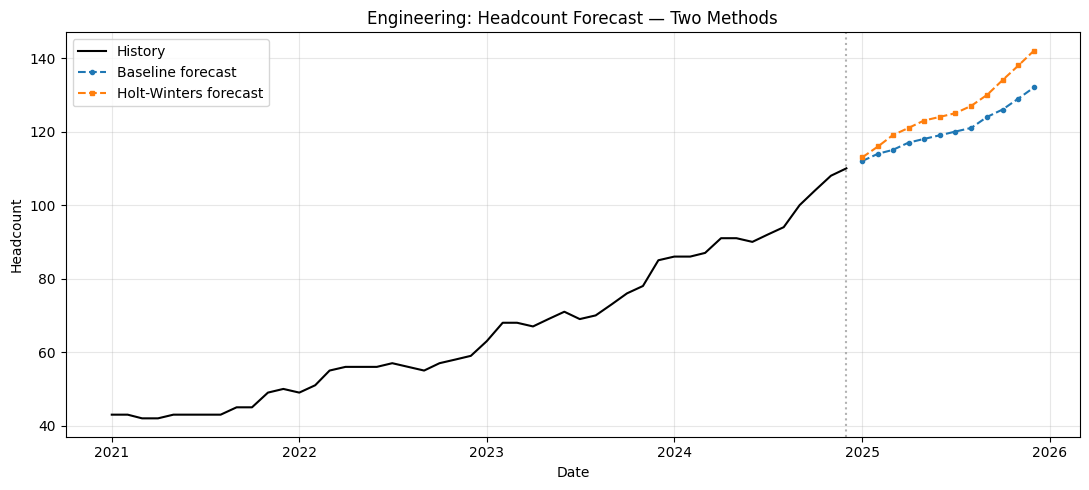

Baseline projects:     132 in 12 months
Holt-Winters projects: 142 in 12 months


In [4]:
plt.figure(figsize=(11, 5))
# History in solid black.
plt.plot(history["date"], history["headcount"], label="History", color="black")
# The two forecasts as dashed lines.
plt.plot(baseline_fc["date"], baseline_fc["headcount"],
         label="Baseline forecast", ls="--", marker="o", ms=3)
plt.plot(hw_fc["date"], hw_fc["headcount"],
         label="Holt-Winters forecast", ls="--", marker="s", ms=3)
# A vertical line marks where history ends and forecast begins.
plt.axvline(history["date"].iloc[-1], color="gray", ls=":", alpha=0.6)
plt.title(f"{DEPARTMENT}: Headcount Forecast — Two Methods")
plt.xlabel("Date"); plt.ylabel("Headcount")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Baseline projects:     {baseline_fc['headcount'].iloc[-1]} in 12 months")
print(f"Holt-Winters projects: {hw_fc['headcount'].iloc[-1]} in 12 months")

**Takeaway:** Both methods agree on the upward direction. Holt-Winters
projects slightly higher because it picks up the recent growth trend more
aggressively, while the baseline leans on longer-run monthly averages. Showing
both gives a planner a sensible range rather than a single false-precision number.

## 5. The key feature — manual overrides for known events

A statistical forecast only knows the past. But planners often know things the
data can't: a hiring class starting in March, a freeze in Q3, a team transfer.

Our `forecast_department` function accepts a list of **overrides**. Each one
targets a specific forecast month and adjusts either **hires** or **leavers**,
in one of two modes:

- **`add`** — stack on top of the model (e.g. "add 8 hires in March").
  Use a negative value to subtract.
- **`replace`** — force a specific value (e.g. "set leavers to 0 — hiring freeze").

`month_index` is 0 for the first forecast month, 1 for the second, and so on.

In [5]:
# Example: the team has approved a hiring wave — 8 extra hires per month
# in March, April, and May (forecast months 2, 3, and 4).
hiring_wave = [
    {"month_index": 2, "field": "hires", "mode": "add", "value": 8},
    {"month_index": 3, "field": "hires", "mode": "add", "value": 8},
    {"month_index": 4, "field": "hires", "mode": "add", "value": 8},
]

# Run the same Holt-Winters forecast, but pass in the overrides.
adjusted_fc = forecast_department(
    df, DEPARTMENT, periods=HORIZON, method="holt_winters", overrides=hiring_wave
)
adjusted_fc

,date,department,hires,leavers,headcount,monthly_salary_cost,monthly_payroll_tax,monthly_benefits,monthly_overhead,monthly_total_cost
0,2025-01-01,Engineering,4,1,113,1337679.97,102332.52,160521.60,133768.00,1734302.08
1,2025-02-01,Engineering,4,1,116,1376580.26,105308.39,165189.63,137658.03,1784736.31
2,2025-03-01,Engineering,12,1,127,1510835.01,115578.88,181300.20,151083.50,1958797.58
3,2025-04-01,Engineering,11,1,137,1633817.91,124987.07,196058.15,163381.79,2118244.93
4,2025-05-01,Engineering,11,1,147,1757398.25,134440.97,210887.79,175739.83,2278466.83
5,2025-06-01,Engineering,2,1,148,1773717.04,135689.35,212846.05,177371.70,2299624.15
6,2025-07-01,Engineering,2,1,149,1790105.64,136943.08,214812.68,179010.56,2320871.96
7,2025-08-01,Engineering,3,1,151,1818608.05,139123.52,218232.97,181860.80,2357825.33
8,2025-09-01,Engineering,4,1,154,1859313.62,142237.49,223117.63,185931.36,2410600.11
9,2025-10-01,Engineering,4,0,158,1912312.16,146291.88,229477.46,191231.22,2479312.71


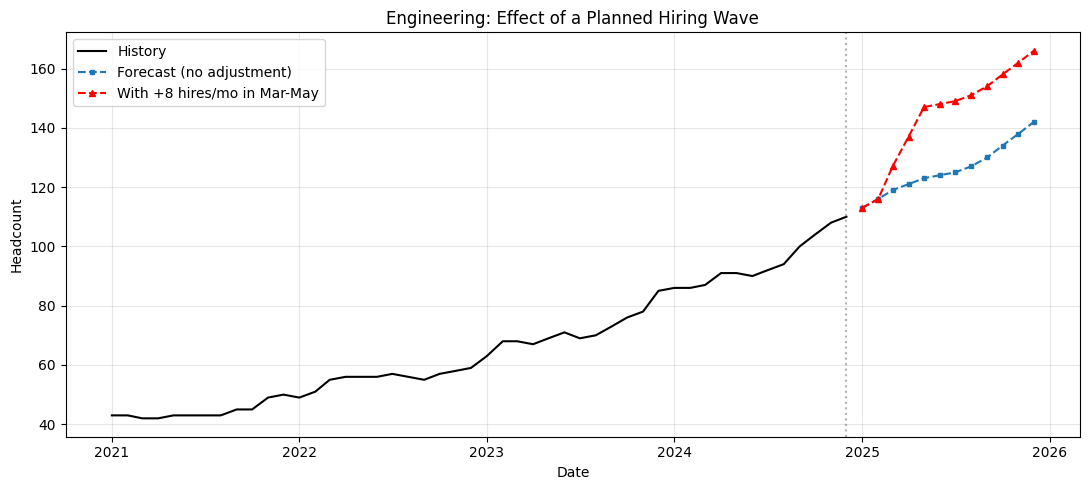

Unadjusted year-end headcount: 142
Adjusted year-end headcount:   166  (+24)


In [6]:
# Plot the adjusted forecast against the unadjusted one to see the impact.
plt.figure(figsize=(11, 5))
plt.plot(history["date"], history["headcount"], label="History", color="black")
plt.plot(hw_fc["date"], hw_fc["headcount"],
         label="Forecast (no adjustment)", ls="--", marker="s", ms=3)
plt.plot(adjusted_fc["date"], adjusted_fc["headcount"],
         label="With +8 hires/mo in Mar-May", ls="--", marker="^", ms=4, color="red")
plt.axvline(history["date"].iloc[-1], color="gray", ls=":", alpha=0.6)
plt.title(f"{DEPARTMENT}: Effect of a Planned Hiring Wave")
plt.xlabel("Date"); plt.ylabel("Headcount")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

diff = adjusted_fc["headcount"].iloc[-1] - hw_fc["headcount"].iloc[-1]
print(f"Unadjusted year-end headcount: {hw_fc['headcount'].iloc[-1]}")
print(f"Adjusted year-end headcount:   {adjusted_fc['headcount'].iloc[-1]}  (+{diff})")

**Takeaway:** The hiring wave lifts the whole forecast curve from the point
it's applied onward — and the year-end headcount rises by the ~24 people added.
This is the difference between a forecast that just extrapolates the past and one
a planning team can actually steer.

A second example below shows **replace** mode: a hiring freeze where we force
leavers to be backfilled (set leavers to 0) for the first quarter.

In [7]:
# Example of REPLACE mode: a Q1 hiring freeze on attrition replacement —
# force leavers to 0 for the first three forecast months.
freeze = [
    {"month_index": 0, "field": "leavers", "mode": "replace", "value": 0},
    {"month_index": 1, "field": "leavers", "mode": "replace", "value": 0},
    {"month_index": 2, "field": "leavers", "mode": "replace", "value": 0},
]
freeze_fc = forecast_department(
    df, DEPARTMENT, periods=HORIZON, method="holt_winters", overrides=freeze
)
# Show that leavers are zeroed out for the first 3 months.
freeze_fc[["date", "hires", "leavers", "headcount"]].head(4)

,date,hires,leavers,headcount
0,2025-01-01,4,0,114
1,2025-02-01,4,0,118
2,2025-03-01,4,0,122
3,2025-04-01,3,1,124


## 6. The finance bridge — fully loaded cost forecast

In [8]:
# An employee costs more than their base salary. Our forecast table breaks
# the cost into four parts, all driven off salary:
#   - salary, payroll taxes (~7.65%), benefits (~12%), overhead (~10%)
# Together these give a "fully loaded" cost ~1.30x salary. Let's see the
# breakdown for the first forecast month.
cost_cols = ["monthly_salary_cost", "monthly_payroll_tax",
             "monthly_benefits", "monthly_overhead", "monthly_total_cost"]
hw_fc[["date"] + cost_cols].head(3)

,date,monthly_salary_cost,monthly_payroll_tax,monthly_benefits,monthly_overhead,monthly_total_cost
0,2025-01-01,1337679.97,102332.52,160521.60,133768.00,1734302.08
1,2025-02-01,1376580.26,105308.39,165189.63,137658.03,1784736.31
2,2025-03-01,1415664.30,108298.32,169879.72,141566.43,1835408.76


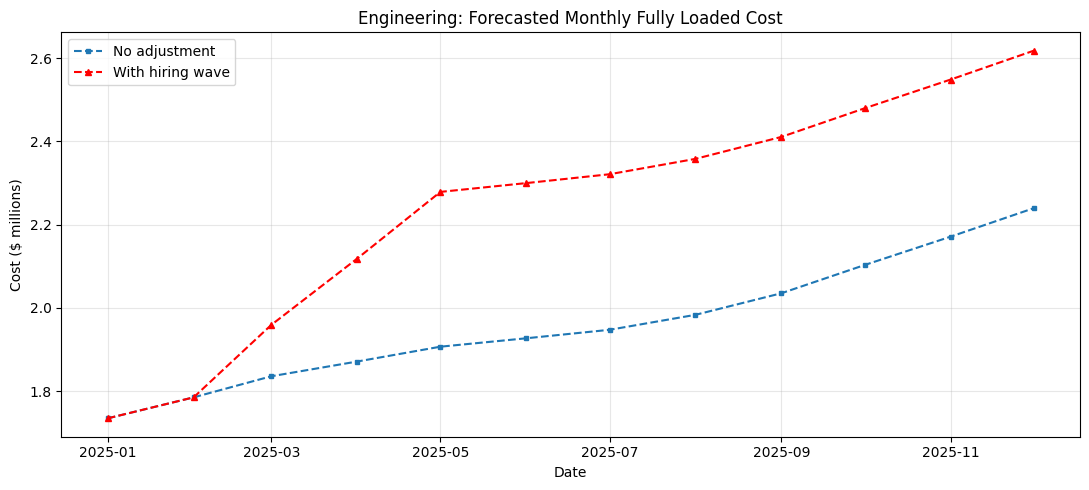

12-month SALARY only (no adjustment):       $18.15M
12-month FULLY LOADED (no adjustment):      $23.54M
12-month FULLY LOADED (with hiring wave):   $26.91M
True cost of the hiring decision:           $3.37M


In [9]:
# Plot the FULLY LOADED total cost (not just salary) for both scenarios.
plt.figure(figsize=(11, 5))
plt.plot(hw_fc["date"], hw_fc["monthly_total_cost"] / 1e6,
         label="No adjustment", ls="--", marker="s", ms=3)
plt.plot(adjusted_fc["date"], adjusted_fc["monthly_total_cost"] / 1e6,
         label="With hiring wave", ls="--", marker="^", ms=4, color="red")
plt.title(f"{DEPARTMENT}: Forecasted Monthly Fully Loaded Cost")
plt.xlabel("Date"); plt.ylabel("Cost ($ millions)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compare salary-only vs fully loaded, and the cost of the hiring decision.
base_salary_annual = hw_fc["monthly_salary_cost"].sum()
base_total_annual = hw_fc["monthly_total_cost"].sum()
wave_total_annual = adjusted_fc["monthly_total_cost"].sum()
print(f"12-month SALARY only (no adjustment):       ${base_salary_annual/1e6:.2f}M")
print(f"12-month FULLY LOADED (no adjustment):      ${base_total_annual/1e6:.2f}M")
print(f"12-month FULLY LOADED (with hiring wave):   ${wave_total_annual/1e6:.2f}M")
print(f"True cost of the hiring decision:           ${(wave_total_annual-base_total_annual)/1e6:.2f}M")

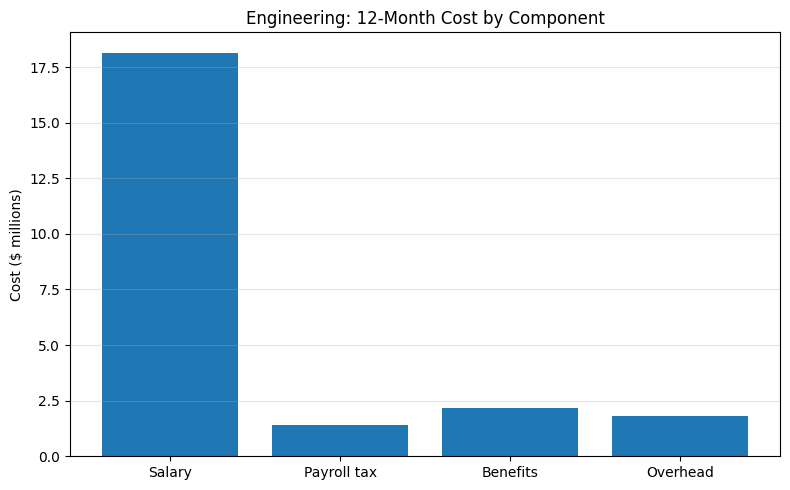

  Salary      : $18.15M
  Payroll tax : $1.39M
  Benefits    : $2.18M
  Overhead    : $1.82M


In [10]:
# Where does the loaded cost come from? Break the first forecast year into
# its four components as a simple stacked picture.
components = {
    "Salary": hw_fc["monthly_salary_cost"].sum() / 1e6,
    "Payroll tax": hw_fc["monthly_payroll_tax"].sum() / 1e6,
    "Benefits": hw_fc["monthly_benefits"].sum() / 1e6,
    "Overhead": hw_fc["monthly_overhead"].sum() / 1e6,
}
plt.figure(figsize=(8, 5))
plt.bar(components.keys(), components.values())
plt.title(f"{DEPARTMENT}: 12-Month Cost by Component")
plt.ylabel("Cost ($ millions)")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

for name, val in components.items():
    print(f"  {name:12s}: ${val:.2f}M")

**Takeaway:** This is the payoff. Budgeting on base salary alone would
understate the real cost by roughly 30% — the payroll taxes, benefits, and
overhead are a large, real part of what a headcount plan actually costs. By
forecasting the *fully loaded* cost, a planner can answer "what does this
hiring decision truly cost the budget?" — and the override feature lets them
test that for any scenario before committing to it.

## Summary

- Two forecasting methods (baseline + Holt-Winters) give a sensible range.
- Per-month overrides in **add** and **replace** modes let planners encode
  known future events on top of the statistical forecast.
- Every scenario converts to a **fully loaded cost** (salary + payroll taxes +
  benefits + overhead, ~1.30x salary), connecting workforce planning to a
  realistic budget number.

**Next:** a Streamlit app wraps this same `forecast_department` function in a
clickable interface, so a non-technical planner can choose a department, pick a
method, and enter overrides without touching code.